In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

In [3]:
query = "SELECT * FROM air_quality"

df = pd.read_sql_query(query, conn)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         112 non-null    int64  
 1   timestamp  112 non-null    object 
 2   aqi        112 non-null    int64  
 3   pm2_5      112 non-null    float64
 4   pm10       112 non-null    float64
 5   co         112 non-null    float64
 6   no2        112 non-null    float64
 7   o3         112 non-null    float64
 8   so2        112 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 8.0+ KB


In [5]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,56.500000,3.169643,40.898661,45.678393,640.158661,16.005625,50.419732,6.348571
std,32.475632,0.642186,15.151214,17.393854,193.561497,7.533680,33.698615,1.361482
min,1.000000,2.000000,14.650000,16.680000,262.580000,1.890000,2.670000,3.050000
25%,28.750000,3.000000,32.017500,34.600000,506.652500,10.900000,18.402500,5.540000
50%,56.500000,3.000000,35.420000,38.900000,651.530000,15.755000,49.850000,6.190000
75%,84.250000,3.000000,49.242500,55.790000,797.285000,21.582500,71.500000,7.165000
max,112.000000,5.000000,80.590000,94.680000,1093.890000,30.130000,134.230000,9.520000


In [6]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

id                    int64
timestamp    datetime64[ns]
aqi                   int64
pm2_5               float64
pm10                float64
co                  float64
no2                 float64
o3                  float64
so2                 float64
dtype: object

In [13]:
#feature engineering
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
107,108,2026-07-27 19:03:50,4,50.63,57.18,624.17,14.24,75.26,6.72,19,27,Monday
108,109,2026-07-27 20:03:44,4,57.55,68.58,774.40,19.11,52.00,7.18,20,27,Monday
109,110,2026-07-27 21:03:44,4,64.93,80.08,914.21,22.80,36.82,7.53,21,27,Monday
110,111,2026-07-27 22:03:49,4,70.96,88.72,1019.20,25.02,27.21,7.69,22,27,Monday
111,112,2026-07-27 23:03:44,5,75.90,94.68,1093.89,25.71,21.69,7.55,23,27,Monday


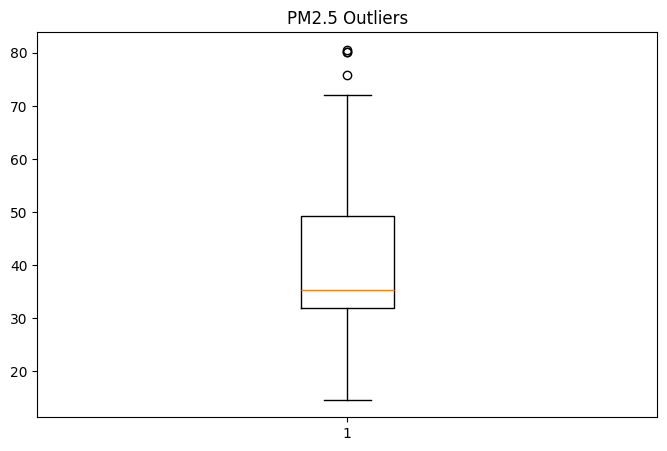

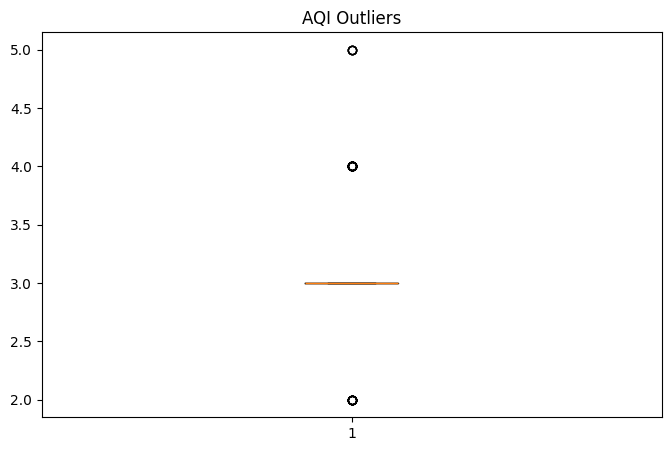

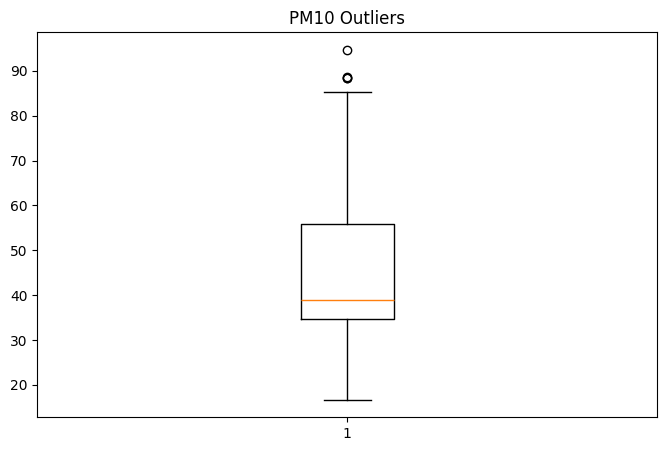

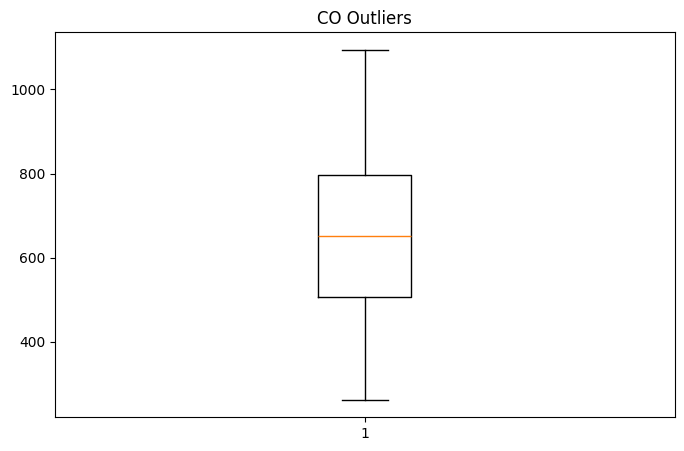

In [14]:
#checking for outliers using boxplots
plt.figure(figsize=(8,5))
plt.boxplot(df["pm2_5"])
plt.title("PM2.5 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["aqi"])
plt.title("AQI Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["pm10"])
plt.title("PM10 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["co"])
plt.title("CO Outliers")
plt.show()



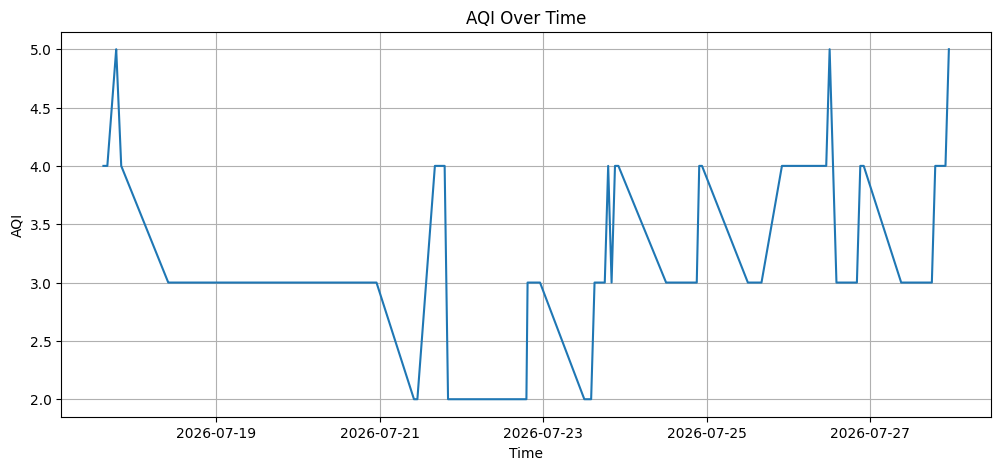

In [15]:
#aqi trend
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["aqi"])

plt.xlabel("Time")

plt.ylabel("AQI")

plt.title("AQI Over Time")

plt.grid(True)

plt.show()

In [16]:
#correlation matrix
corr = df.corr(numeric_only=True)
corr

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,0.108642,0.057064,0.112295,-0.141805,-0.114213,0.115632,0.006168,0.234286,0.991441
aqi,0.108642,1.000000,0.908776,0.898571,0.359374,0.080152,0.301439,0.256539,0.161777,0.118389
pm2_5,0.057064,0.908776,1.000000,0.985283,0.370137,0.045099,0.372670,0.329922,0.079200,0.073948
pm10,0.112295,0.898571,0.985283,1.000000,0.455422,0.140516,0.275703,0.412645,0.148730,0.122977
co,-0.141805,0.359374,0.370137,0.455422,1.000000,0.896532,-0.684363,0.680986,0.063137,-0.162816
no2,-0.114213,0.080152,0.045099,0.140516,0.896532,1.000000,-0.845018,0.650233,0.156103,-0.164608
o3,0.115632,0.301439,0.372670,0.275703,-0.684363,-0.845018,1.000000,-0.378246,-0.013616,0.151300
so2,0.006168,0.256539,0.329922,0.412645,0.680986,0.650233,-0.378246,1.000000,0.302373,-0.039432
hour,0.234286,0.161777,0.079200,0.148730,0.063137,0.156103,-0.013616,0.302373,1.000000,0.140411
day,0.991441,0.118389,0.073948,0.122977,-0.162816,-0.164608,0.151300,-0.039432,0.140411,1.000000


In [17]:
df.to_csv("../data/processed_air_quality.csv",index=False)

In [18]:
df.to_sql(
    "processed_air_quality",
    conn,
    if_exists="replace",
    index=False
)

112

In [19]:
conn.close()